<a href="https://colab.research.google.com/github/gerald-hlabiso/business-analytics-portfolio/blob/main/projects/sunrise-hospital-emr-analytics/sunrise-hospital-emr-analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sunrise Hospital Patient Operations & EMR Analytics

## Project Overview

This project develops an end-to-end hospital operations analytics workflow using synthetic patient and encounter data. It demonstrates how electronic medical record data can support patient-flow monitoring, resource planning, operational-risk assessment, and management reporting.

## Business Question

**How can hospital encounter data help administrators monitor patient flow, identify operational pressure points, and prioritize opportunities to improve hospital performance?**

## Project Objectives

- Generate a reproducible synthetic hospital dataset
- Validate patient and encounter data quality
- Analyze admissions, discharges, departments, and encounter types
- Measure waiting time, length of stay, readmissions, and appointment no-shows
- Develop operational risk indicators
- Prepare analytical tables for a Power BI dashboard
- Communicate findings with appropriate privacy and responsible-use safeguards

## Responsible-Use Notice

This project uses entirely synthetic data created for educational and portfolio purposes. It contains no real patient records or protected health information.

The analysis is intended for hospital operations planning and demonstration only. It is not a diagnostic model, medical advice, or a validated clinical decision-support system.

In [14]:
# Core data libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# File and reproducibility utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Visualization theme
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

# Output directory
OUTPUT_DIR = Path("sunrise_hospital_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Environment configured successfully.")
print("Random state:", RANDOM_STATE)
print("Output directory:", OUTPUT_DIR.resolve())

Environment configured successfully.
Random state: 42
Output directory: /content/sunrise_hospital_outputs


## 1. Synthetic Data Generation

The project creates reproducible synthetic patient and hospital-encounter records. The data represents realistic operational patterns but does not describe real individuals or a real hospital.

In [15]:
# ---------------------------------------------------------
# Generate synthetic patient demographic records
# ---------------------------------------------------------

N_PATIENTS = 3_000

patient_ids = [
    f"PT-{number:05d}"
    for number in range(1, N_PATIENTS + 1)
]

date_of_birth = pd.to_datetime(
    rng.choice(
        pd.date_range(
            start="1935-01-01",
            end="2008-12-31",
            freq="D"
        ),
        size=N_PATIENTS,
        replace=True
    )
)

sex = rng.choice(
    ["Female", "Male"],
    size=N_PATIENTS,
    p=[0.52, 0.48]
)

race_ethnicity = rng.choice(
    [
        "White",
        "Black or African American",
        "Hispanic or Latino",
        "Asian",
        "Other or Multiple"
    ],
    size=N_PATIENTS,
    p=[0.49, 0.25, 0.14, 0.07, 0.05]
)

insurance_type = rng.choice(
    [
        "Commercial",
        "Medicare",
        "Medicaid",
        "Self-Pay"
    ],
    size=N_PATIENTS,
    p=[0.43, 0.29, 0.21, 0.07]
)

home_region = rng.choice(
    [
        "Central",
        "North",
        "South",
        "East",
        "West"
    ],
    size=N_PATIENTS,
    p=[0.30, 0.18, 0.20, 0.17, 0.15]
)

patients_df = pd.DataFrame({
    "patient_id": patient_ids,
    "date_of_birth": date_of_birth,
    "sex": sex,
    "race_ethnicity": race_ethnicity,
    "insurance_type": insurance_type,
    "home_region": home_region
})

# Remove any accidental duplicate patient records
patients_df = (
    patients_df
    .drop_duplicates(subset="patient_id")
    .sort_values("patient_id")
    .reset_index(drop=True)
)

print("=" * 70)
print("SYNTHETIC PATIENT TABLE")
print("=" * 70)
print(f"Rows: {len(patients_df):,}")
print(f"Unique patients: {patients_df['patient_id'].nunique():,}")
print(f"Duplicate patient IDs: {patients_df['patient_id'].duplicated().sum():,}")
print(f"Missing values: {patients_df.isna().sum().sum():,}")

display(patients_df.head())

SYNTHETIC PATIENT TABLE
Rows: 3,000
Unique patients: 3,000
Duplicate patient IDs: 0
Missing values: 0


,patient_id,date_of_birth,sex,race_ethnicity,insurance_type,home_region
0,PT-00001,1941-08-09,Male,White,Medicare,North
1,PT-00002,1992-04-10,Male,White,Medicaid,Central
2,PT-00003,1983-06-10,Female,Black or African American,Commercial,Central
3,PT-00004,1967-06-24,Female,White,Medicare,South
4,PT-00005,1967-01-16,Male,White,Medicare,East


In [16]:
# ---------------------------------------------------------
# Generate synthetic hospital encounter records
# ---------------------------------------------------------

N_ENCOUNTERS = 12_000

encounter_ids = [
    f"ENC-{number:06d}"
    for number in range(1, N_ENCOUNTERS + 1)
]

# Patients may have multiple encounters
encounter_patient_ids = rng.choice(
    patients_df["patient_id"],
    size=N_ENCOUNTERS,
    replace=True
)

# Complete two-year analytical period
analysis_start = pd.Timestamp("2024-01-01")
analysis_end = pd.Timestamp("2025-12-31 23:59:59")

total_seconds = int(
    (analysis_end - analysis_start).total_seconds()
)

scheduled_datetime = (
    analysis_start
    + pd.to_timedelta(
        rng.integers(
            low=0,
            high=total_seconds,
            size=N_ENCOUNTERS
        ),
        unit="s"
    )
)

encounter_type = rng.choice(
    ["Outpatient", "Emergency", "Inpatient"],
    size=N_ENCOUNTERS,
    p=[0.55, 0.27, 0.18]
)

# Department assignment varies by encounter type
department_options = {
    "Outpatient": [
        "Primary Care",
        "Cardiology",
        "Orthopedics",
        "Neurology",
        "Pediatrics",
        "Behavioral Health"
    ],
    "Emergency": [
        "Emergency Department"
    ],
    "Inpatient": [
        "General Medicine",
        "Cardiology",
        "Orthopedics",
        "Neurology",
        "Intensive Care"
    ]
}

department = np.array([
    rng.choice(department_options[current_type])
    for current_type in encounter_type
])

severity = []

for current_type in encounter_type:
    if current_type == "Outpatient":
        severity.append(
            rng.choice(
                ["Low", "Moderate", "High"],
                p=[0.65, 0.30, 0.05]
            )
        )

    elif current_type == "Emergency":
        severity.append(
            rng.choice(
                ["Low", "Moderate", "High", "Critical"],
                p=[0.22, 0.45, 0.25, 0.08]
            )
        )

    else:
        severity.append(
            rng.choice(
                ["Moderate", "High", "Critical"],
                p=[0.42, 0.43, 0.15]
            )
        )

severity = np.array(severity)

# No-shows apply only to outpatient appointments
no_show_flag = np.zeros(N_ENCOUNTERS, dtype=int)

outpatient_mask = encounter_type == "Outpatient"

no_show_flag[outpatient_mask] = rng.binomial(
    n=1,
    p=0.11,
    size=outpatient_mask.sum()
)

# Waiting-time assumptions by encounter type
wait_minutes = np.zeros(N_ENCOUNTERS)

wait_minutes[outpatient_mask] = rng.gamma(
    shape=2.0,
    scale=9.0,
    size=outpatient_mask.sum()
)

emergency_mask = encounter_type == "Emergency"

wait_minutes[emergency_mask] = rng.gamma(
    shape=2.5,
    scale=18.0,
    size=emergency_mask.sum()
)

inpatient_mask = encounter_type == "Inpatient"

wait_minutes[inpatient_mask] = rng.gamma(
    shape=2.0,
    scale=12.0,
    size=inpatient_mask.sum()
)

# High operational pressure increases some waiting times
pressure_event = rng.binomial(
    n=1,
    p=0.12,
    size=N_ENCOUNTERS
)

wait_minutes = (
    wait_minutes
    + pressure_event * rng.uniform(
        20,
        75,
        size=N_ENCOUNTERS
    )
)

wait_minutes = np.round(
    np.clip(wait_minutes, 0, 240),
    1
)

# No-show appointments have no observed waiting time
wait_minutes = pd.Series(wait_minutes)
wait_minutes.loc[no_show_flag == 1] = np.nan

# Encounter duration assumptions
length_of_stay_hours = np.zeros(N_ENCOUNTERS)

completed_outpatient_mask = (
    outpatient_mask
    & (no_show_flag == 0)
)

length_of_stay_hours[completed_outpatient_mask] = rng.uniform(
    0.5,
    3.0,
    size=completed_outpatient_mask.sum()
)

length_of_stay_hours[emergency_mask] = rng.gamma(
    shape=2.5,
    scale=2.0,
    size=emergency_mask.sum()
)

length_of_stay_hours[inpatient_mask] = rng.gamma(
    shape=3.0,
    scale=28.0,
    size=inpatient_mask.sum()
)

length_of_stay_hours = np.round(
    np.clip(length_of_stay_hours, 0, 500),
    1
)

length_of_stay_hours = pd.Series(
    length_of_stay_hours
)

length_of_stay_hours.loc[
    no_show_flag == 1
] = np.nan

# Arrival time occurs after the scheduled or recorded encounter time
arrival_datetime = (
    pd.Series(scheduled_datetime)
    + pd.to_timedelta(
        wait_minutes.fillna(0),
        unit="m"
    )
)

arrival_datetime.loc[
    no_show_flag == 1
] = pd.NaT

discharge_datetime = (
    arrival_datetime
    + pd.to_timedelta(
        length_of_stay_hours.fillna(0),
        unit="h"
    )
)

discharge_datetime.loc[
    no_show_flag == 1
] = pd.NaT

diagnosis_categories = [
    "Cardiovascular",
    "Respiratory",
    "Endocrine",
    "Musculoskeletal",
    "Neurological",
    "Gastrointestinal",
    "Behavioral Health",
    "Injury",
    "Preventive Care",
    "Other"
]

diagnosis_category = rng.choice(
    diagnosis_categories,
    size=N_ENCOUNTERS,
    p=[
        0.14,
        0.13,
        0.11,
        0.13,
        0.08,
        0.09,
        0.07,
        0.09,
        0.10,
        0.06
    ]
)

discharge_disposition = []

for index in range(N_ENCOUNTERS):

    if no_show_flag[index] == 1:
        discharge_disposition.append(
            "No Show"
        )

    elif encounter_type[index] == "Outpatient":
        discharge_disposition.append(
            rng.choice(
                [
                    "Home",
                    "Follow-Up Required"
                ],
                p=[0.79, 0.21]
            )
        )

    elif encounter_type[index] == "Emergency":
        discharge_disposition.append(
            rng.choice(
                [
                    "Home",
                    "Admitted",
                    "Transferred",
                    "Left Before Completion"
                ],
                p=[0.68, 0.23, 0.05, 0.04]
            )
        )

    else:
        discharge_disposition.append(
            rng.choice(
                [
                    "Home",
                    "Skilled Nursing Facility",
                    "Rehabilitation",
                    "Transferred"
                ],
                p=[0.71, 0.13, 0.11, 0.05]
            )
        )

encounters_df = pd.DataFrame({
    "encounter_id": encounter_ids,
    "patient_id": encounter_patient_ids,
    "scheduled_datetime": scheduled_datetime,
    "arrival_datetime": arrival_datetime,
    "discharge_datetime": discharge_datetime,
    "encounter_type": encounter_type,
    "department": department,
    "severity": severity,
    "diagnosis_category": diagnosis_category,
    "insurance_type_at_encounter": rng.choice(
        [
            "Commercial",
            "Medicare",
            "Medicaid",
            "Self-Pay"
        ],
        size=N_ENCOUNTERS,
        p=[0.43, 0.29, 0.21, 0.07]
    ),
    "wait_minutes": wait_minutes,
    "length_of_stay_hours": length_of_stay_hours,
    "no_show_flag": no_show_flag,
    "discharge_disposition": discharge_disposition
})

encounters_df = (
    encounters_df
    .sort_values(
        [
            "patient_id",
            "scheduled_datetime"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("SYNTHETIC HOSPITAL ENCOUNTER TABLE")
print("=" * 70)
print(f"Rows: {len(encounters_df):,}")
print(
    "Unique encounters:",
    f"{encounters_df['encounter_id'].nunique():,}"
)
print(
    "Unique patients represented:",
    f"{encounters_df['patient_id'].nunique():,}"
)
print(
    "Duplicate encounter IDs:",
    f"{encounters_df['encounter_id'].duplicated().sum():,}"
)
print(
    "No-show encounters:",
    f"{encounters_df['no_show_flag'].sum():,}"
)

display(encounters_df.head())

SYNTHETIC HOSPITAL ENCOUNTER TABLE
Rows: 12,000
Unique encounters: 12,000
Unique patients represented: 2,940
Duplicate encounter IDs: 0
No-show encounters: 752


,encounter_id,patient_id,scheduled_datetime,arrival_datetime,discharge_datetime,encounter_type,department,severity,diagnosis_category,insurance_type_at_encounter,wait_minutes,length_of_stay_hours,no_show_flag,discharge_disposition
0,ENC-000687,PT-00001,2024-01-24 11:45:34,2024-01-24 12:03:22,2024-01-24 14:33:22,Outpatient,Pediatrics,Moderate,Preventive Care,Medicare,17.80,2.50,0,Home
1,ENC-010968,PT-00001,2025-08-09 20:26:45,2025-08-09 20:39:21,2025-08-09 23:21:21,Outpatient,Primary Care,Moderate,Other,Medicaid,12.60,2.70,0,Home
2,ENC-011110,PT-00001,2025-08-12 03:17:47,2025-08-12 03:23:59,2025-08-12 05:35:59,Outpatient,Primary Care,Low,Cardiovascular,Medicare,6.20,2.20,0,Home
3,ENC-005420,PT-00001,2025-10-08 01:44:46,2025-10-08 02:43:16,2025-10-08 05:13:16,Outpatient,Pediatrics,Low,Cardiovascular,Self-Pay,58.50,2.50,0,Home
4,ENC-002547,PT-00001,2025-10-25 10:35:00,2025-10-25 10:37:18,2025-10-25 12:55:18,Outpatient,Behavioral Health,Low,Behavioral Health,Commercial,2.30,2.30,0,Home


## 2. Analytical Dataset Construction

Patient demographics are joined to hospital encounters. Operational fields are then derived, including patient age, encounter month, waiting-time flags, extended-stay flags, and a synthetic 30-day inpatient readmission indicator.

In [17]:
# ---------------------------------------------------------
# Join patients and encounters
# ---------------------------------------------------------

emr_df = encounters_df.merge(
    patients_df,
    on="patient_id",
    how="left",
    validate="many_to_one",
    suffixes=("_encounter", "_patient")
)

# Use the insurance field recorded at the encounter
emr_df["insurance_type"] = (
    emr_df["insurance_type_at_encounter"]
)

emr_df = emr_df.drop(
    columns=[
        "insurance_type_at_encounter",
        "insurance_type_patient"
    ],
    errors="ignore"
)

# ---------------------------------------------------------
# Derive calendar and patient-age fields
# ---------------------------------------------------------

emr_df["encounter_date"] = (
    emr_df["scheduled_datetime"].dt.date
)

emr_df["encounter_year"] = (
    emr_df["scheduled_datetime"].dt.year
)

emr_df["encounter_month_number"] = (
    emr_df["scheduled_datetime"].dt.month
)

emr_df["encounter_month_name"] = (
    emr_df["scheduled_datetime"].dt.month_name()
)

emr_df["year_month"] = (
    emr_df["scheduled_datetime"]
    .dt.to_period("M")
    .astype(str)
)

emr_df["day_of_week"] = (
    emr_df["scheduled_datetime"].dt.day_name()
)

emr_df["encounter_hour"] = (
    emr_df["scheduled_datetime"].dt.hour
)

emr_df["patient_age"] = np.floor(
    (
        emr_df["scheduled_datetime"]
        - emr_df["date_of_birth"]
    ).dt.days / 365.25
).astype(int)

emr_df["age_group"] = pd.cut(
    emr_df["patient_age"],
    bins=[
        -1,
        17,
        34,
        49,
        64,
        79,
        np.inf
    ],
    labels=[
        "0–17",
        "18–34",
        "35–49",
        "50–64",
        "65–79",
        "80+"
    ]
)

# ---------------------------------------------------------
# Operational indicators
# ---------------------------------------------------------

emr_df["completed_encounter_flag"] = (
    emr_df["no_show_flag"] == 0
).astype(int)

emr_df["extended_wait_flag"] = (
    (
        emr_df["encounter_type"] == "Emergency"
    )
    & (
        emr_df["wait_minutes"] > 60
    )
).astype(int)

emr_df["extended_stay_flag"] = (
    (
        emr_df["encounter_type"] == "Inpatient"
    )
    & (
        emr_df["length_of_stay_hours"] > 120
    )
).astype(int)

emr_df["left_before_completion_flag"] = (
    emr_df["discharge_disposition"]
    == "Left Before Completion"
).astype(int)

# ---------------------------------------------------------
# Create a 30-day inpatient readmission indicator
# ---------------------------------------------------------

emr_df["readmission_30_day_flag"] = 0

inpatient_records = (
    emr_df.loc[
        (
            emr_df["encounter_type"] == "Inpatient"
        )
        & (
            emr_df["no_show_flag"] == 0
        )
    ]
    .sort_values(
        [
            "patient_id",
            "scheduled_datetime"
        ]
    )
    .copy()
)

inpatient_records["previous_discharge_datetime"] = (
    inpatient_records
    .groupby("patient_id")[
        "discharge_datetime"
    ]
    .shift(1)
)

inpatient_records["days_since_previous_discharge"] = (
    (
        inpatient_records["scheduled_datetime"]
        - inpatient_records[
            "previous_discharge_datetime"
        ]
    ).dt.total_seconds()
    / 86_400
)

inpatient_records["readmission_30_day_flag"] = (
    inpatient_records[
        "days_since_previous_discharge"
    ]
    .between(
        0,
        30,
        inclusive="both"
    )
    .astype(int)
)

emr_df.loc[
    inpatient_records.index,
    "readmission_30_day_flag"
] = inpatient_records[
    "readmission_30_day_flag"
]

# ---------------------------------------------------------
# Create an operational pressure indicator
# ---------------------------------------------------------

emr_df["operational_pressure_flag"] = (
    (
        emr_df["extended_wait_flag"] == 1
    )
    | (
        emr_df["extended_stay_flag"] == 1
    )
    | (
        emr_df["left_before_completion_flag"] == 1
    )
    | (
        emr_df["readmission_30_day_flag"] == 1
    )
).astype(int)

# Arrange the dataset
emr_df = (
    emr_df
    .sort_values("scheduled_datetime")
    .reset_index(drop=True)
)

print("=" * 75)
print("ANALYTICAL EMR TABLE")
print("=" * 75)
print(f"Rows: {len(emr_df):,}")
print(
    "Unique encounters:",
    f"{emr_df['encounter_id'].nunique():,}"
)
print(
    "Unique patients:",
    f"{emr_df['patient_id'].nunique():,}"
)
print(
    "Thirty-day inpatient readmissions:",
    f"{emr_df['readmission_30_day_flag'].sum():,}"
)
print(
    "Operational-pressure encounters:",
    f"{emr_df['operational_pressure_flag'].sum():,}"
)

display(
    emr_df[
        [
            "encounter_id",
            "patient_id",
            "scheduled_datetime",
            "patient_age",
            "encounter_type",
            "department",
            "wait_minutes",
            "length_of_stay_hours",
            "no_show_flag",
            "readmission_30_day_flag",
            "operational_pressure_flag"
        ]
    ].head()
)

ANALYTICAL EMR TABLE
Rows: 12,000
Unique encounters: 12,000
Unique patients: 2,940
Thirty-day inpatient readmissions: 71
Operational-pressure encounters: 1,614


,encounter_id,patient_id,scheduled_datetime,patient_age,encounter_type,department,wait_minutes,length_of_stay_hours,no_show_flag,readmission_30_day_flag,operational_pressure_flag
0,ENC-010782,PT-00198,2024-01-01 00:03:10,80,Outpatient,Cardiology,NaN,NaN,1,0,0
1,ENC-011989,PT-02483,2024-01-01 02:26:01,75,Emergency,Emergency Department,30.90,4.60,0,0,0
2,ENC-007337,PT-00320,2024-01-01 03:00:11,32,Outpatient,Behavioral Health,NaN,NaN,1,0,0
3,ENC-008075,PT-02045,2024-01-01 03:19:38,68,Inpatient,Intensive Care,22.70,62.60,0,0,0
4,ENC-008031,PT-02116,2024-01-01 05:08:20,74,Outpatient,Cardiology,100.00,0.60,0,0,0


## 3. Data-Quality Validation

Before calculating hospital-performance indicators, the analytical table is checked for duplicate identifiers, missing relationships, invalid ages, inconsistent timestamps, negative durations, and unexpected category values.

In [18]:
# ---------------------------------------------------------
# Data-quality validation
# ---------------------------------------------------------

validation_results = []

def add_validation_check(
    check_name,
    failed_records,
    expected_result
):
    validation_results.append({
        "check": check_name,
        "failed_records": int(failed_records),
        "expected_result": expected_result,
        "status": (
            "Pass"
            if int(failed_records) == 0
            else "Review"
        )
    })


# 1. Encounter IDs must be unique
add_validation_check(
    check_name="Duplicate encounter IDs",
    failed_records=emr_df[
        "encounter_id"
    ].duplicated().sum(),
    expected_result="0"
)

# 2. All encounters must match a patient
add_validation_check(
    check_name="Encounters without patient records",
    failed_records=emr_df[
        "date_of_birth"
    ].isna().sum(),
    expected_result="0"
)

# 3. Patient age must be plausible
add_validation_check(
    check_name="Patient age outside 0–100",
    failed_records=(
        ~emr_df["patient_age"].between(
            0,
            100
        )
    ).sum(),
    expected_result="0"
)

# 4. Arrival cannot occur before the scheduled time
add_validation_check(
    check_name="Arrival before scheduled time",
    failed_records=(
        (
            emr_df["arrival_datetime"]
            < emr_df["scheduled_datetime"]
        )
        & (
            emr_df["no_show_flag"] == 0
        )
    ).sum(),
    expected_result="0"
)

# 5. Discharge cannot occur before arrival
add_validation_check(
    check_name="Discharge before arrival",
    failed_records=(
        emr_df["discharge_datetime"]
        < emr_df["arrival_datetime"]
    ).sum(),
    expected_result="0"
)

# 6. Waiting time cannot be negative
add_validation_check(
    check_name="Negative waiting time",
    failed_records=(
        emr_df["wait_minutes"] < 0
    ).sum(),
    expected_result="0"
)

# 7. Length of stay cannot be negative
add_validation_check(
    check_name="Negative length of stay",
    failed_records=(
        emr_df["length_of_stay_hours"] < 0
    ).sum(),
    expected_result="0"
)

# 8. No-shows should not have arrival timestamps
add_validation_check(
    check_name="No-shows with arrival timestamps",
    failed_records=(
        (
            emr_df["no_show_flag"] == 1
        )
        & (
            emr_df["arrival_datetime"].notna()
        )
    ).sum(),
    expected_result="0"
)

# 9. Completed encounters require arrival timestamps
add_validation_check(
    check_name="Completed encounters without arrival",
    failed_records=(
        (
            emr_df["no_show_flag"] == 0
        )
        & (
            emr_df["arrival_datetime"].isna()
        )
    ).sum(),
    expected_result="0"
)

# 10. Encounter type must be recognized
valid_encounter_types = {
    "Outpatient",
    "Emergency",
    "Inpatient"
}

add_validation_check(
    check_name="Unexpected encounter types",
    failed_records=(
        ~emr_df["encounter_type"].isin(
            valid_encounter_types
        )
    ).sum(),
    expected_result="0"
)

validation_df = pd.DataFrame(
    validation_results
)

print("=" * 75)
print("DATA-QUALITY VALIDATION RESULTS")
print("=" * 75)

display(validation_df)

overall_validation_status = (
    "PASS"
    if (
        validation_df["status"] == "Pass"
    ).all()
    else "REVIEW REQUIRED"
)

print(
    "\nOverall validation status:",
    overall_validation_status
)

print(
    "Total failed records across checks:",
    validation_df["failed_records"].sum()
)

DATA-QUALITY VALIDATION RESULTS


,check,failed_records,expected_result,status
0,Duplicate encounter IDs,0,0,Pass
1,Encounters without patient records,0,0,Pass
2,Patient age outside 0–100,0,0,Pass
3,Arrival before scheduled time,0,0,Pass
4,Discharge before arrival,0,0,Pass
5,Negative waiting time,0,0,Pass
6,Negative length of stay,0,0,Pass
7,No-shows with arrival timestamps,0,0,Pass
8,Completed encounters without arrival,0,0,Pass
9,Unexpected encounter types,0,0,Pass



Overall validation status: PASS
Total failed records across checks: 0


## 4. Hospital Operations KPIs

Key performance indicators summarize patient volume, emergency waiting time, inpatient length of stay, outpatient no-shows, 30-day readmissions, and encounters associated with operational pressure.

In [19]:
# ---------------------------------------------------------
# Calculate hospital operations KPIs
# ---------------------------------------------------------

completed_df = emr_df.loc[
    emr_df["completed_encounter_flag"] == 1
].copy()

emergency_df = emr_df.loc[
    (
        emr_df["encounter_type"] == "Emergency"
    )
    & (
        emr_df["completed_encounter_flag"] == 1
    )
].copy()

inpatient_df = emr_df.loc[
    (
        emr_df["encounter_type"] == "Inpatient"
    )
    & (
        emr_df["completed_encounter_flag"] == 1
    )
].copy()

outpatient_df = emr_df.loc[
    emr_df["encounter_type"] == "Outpatient"
].copy()

total_encounters = len(emr_df)

completed_encounters = (
    emr_df["completed_encounter_flag"].sum()
)

unique_patients = (
    emr_df["patient_id"].nunique()
)

average_ed_wait_minutes = (
    emergency_df["wait_minutes"].mean()
)

median_ed_wait_minutes = (
    emergency_df["wait_minutes"].median()
)

average_inpatient_los_days = (
    inpatient_df["length_of_stay_hours"].mean()
    / 24
)

median_inpatient_los_days = (
    inpatient_df["length_of_stay_hours"].median()
    / 24
)

outpatient_no_show_rate = (
    outpatient_df["no_show_flag"].mean()
)

inpatient_readmission_rate = (
    inpatient_df["readmission_30_day_flag"].mean()
)

extended_ed_wait_rate = (
    emergency_df["extended_wait_flag"].mean()
)

extended_inpatient_stay_rate = (
    inpatient_df["extended_stay_flag"].mean()
)

operational_pressure_rate = (
    emr_df["operational_pressure_flag"].mean()
)

kpi_df = pd.DataFrame({
    "KPI": [
        "Total Encounters",
        "Completed Encounters",
        "Unique Patients",
        "Average ED Wait",
        "Median ED Wait",
        "Average Inpatient Length of Stay",
        "Median Inpatient Length of Stay",
        "Outpatient No-Show Rate",
        "30-Day Inpatient Readmission Rate",
        "ED Wait Over 60 Minutes",
        "Inpatient Stay Over 5 Days",
        "Operational-Pressure Encounter Rate"
    ],
    "Value": [
        total_encounters,
        completed_encounters,
        unique_patients,
        average_ed_wait_minutes,
        median_ed_wait_minutes,
        average_inpatient_los_days,
        median_inpatient_los_days,
        outpatient_no_show_rate,
        inpatient_readmission_rate,
        extended_ed_wait_rate,
        extended_inpatient_stay_rate,
        operational_pressure_rate
    ],
    "Unit": [
        "Encounters",
        "Encounters",
        "Patients",
        "Minutes",
        "Minutes",
        "Days",
        "Days",
        "Percentage",
        "Percentage",
        "Percentage",
        "Percentage",
        "Percentage"
    ]
})

kpi_display_df = kpi_df.copy()

for row_index in kpi_display_df.index:

    unit = kpi_display_df.loc[
        row_index,
        "Unit"
    ]

    value = kpi_display_df.loc[
        row_index,
        "Value"
    ]

    if unit in [
        "Encounters",
        "Patients"
    ]:
        formatted_value = f"{value:,.0f}"

    elif unit == "Percentage":
        formatted_value = f"{value:.1%}"

    elif unit == "Minutes":
        formatted_value = f"{value:,.1f}"

    else:
        formatted_value = f"{value:,.2f}"

    kpi_display_df.loc[
        row_index,
        "Formatted Value"
    ] = formatted_value

print("=" * 80)
print("SUNRISE HOSPITAL OPERATIONS KPI SUMMARY")
print("=" * 80)

display(
    kpi_display_df[
        [
            "KPI",
            "Formatted Value",
            "Unit"
        ]
    ]
)

SUNRISE HOSPITAL OPERATIONS KPI SUMMARY


,KPI,Formatted Value,Unit
0,Total Encounters,"12,000",Encounters
1,Completed Encounters,"11,248",Encounters
2,Unique Patients,"2,940",Patients
3,Average ED Wait,51.1,Minutes
4,Median ED Wait,43.5,Minutes
5,Average Inpatient Length of Stay,3.48,Days
6,Median Inpatient Length of Stay,3.12,Days
7,Outpatient No-Show Rate,11.4%,Percentage
8,30-Day Inpatient Readmission Rate,3.3%,Percentage
9,ED Wait Over 60 Minutes,32.0%,Percentage


In [20]:
# ---------------------------------------------------------
# Department-level performance summary
# ---------------------------------------------------------

department_summary_df = (
    emr_df
    .groupby(
        "department",
        as_index=False
    )
    .agg(
        total_encounters=(
            "encounter_id",
            "count"
        ),
        unique_patients=(
            "patient_id",
            "nunique"
        ),
        completed_encounters=(
            "completed_encounter_flag",
            "sum"
        ),
        average_wait_minutes=(
            "wait_minutes",
            "mean"
        ),
        average_length_of_stay_hours=(
            "length_of_stay_hours",
            "mean"
        ),
        no_show_rate=(
            "no_show_flag",
            "mean"
        ),
        readmission_30_day_rate=(
            "readmission_30_day_flag",
            "mean"
        ),
        extended_wait_rate=(
            "extended_wait_flag",
            "mean"
        ),
        extended_stay_rate=(
            "extended_stay_flag",
            "mean"
        ),
        operational_pressure_rate=(
            "operational_pressure_flag",
            "mean"
        )
    )
)

department_summary_df[
    "average_length_of_stay_days"
] = (
    department_summary_df[
        "average_length_of_stay_hours"
    ]
    / 24
)

department_summary_df = (
    department_summary_df
    .drop(
        columns=[
            "average_length_of_stay_hours"
        ]
    )
    .sort_values(
        "total_encounters",
        ascending=False
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Monthly performance summary
# ---------------------------------------------------------

monthly_summary_df = (
    emr_df
    .groupby(
        "year_month",
        as_index=False
    )
    .agg(
        total_encounters=(
            "encounter_id",
            "count"
        ),
        unique_patients=(
            "patient_id",
            "nunique"
        ),
        completed_encounters=(
            "completed_encounter_flag",
            "sum"
        ),
        outpatient_no_shows=(
            "no_show_flag",
            "sum"
        ),
        average_wait_minutes=(
            "wait_minutes",
            "mean"
        ),
        average_length_of_stay_hours=(
            "length_of_stay_hours",
            "mean"
        ),
        readmissions_30_day=(
            "readmission_30_day_flag",
            "sum"
        ),
        operational_pressure_encounters=(
            "operational_pressure_flag",
            "sum"
        )
    )
)

monthly_summary_df["month_start"] = pd.to_datetime(
    monthly_summary_df["year_month"]
    + "-01"
)

monthly_summary_df["completion_rate"] = (
    monthly_summary_df[
        "completed_encounters"
    ]
    / monthly_summary_df[
        "total_encounters"
    ]
)

monthly_summary_df[
    "operational_pressure_rate"
] = (
    monthly_summary_df[
        "operational_pressure_encounters"
    ]
    / monthly_summary_df[
        "total_encounters"
    ]
)

monthly_summary_df[
    "average_length_of_stay_days"
] = (
    monthly_summary_df[
        "average_length_of_stay_hours"
    ]
    / 24
)

monthly_summary_df = (
    monthly_summary_df
    .drop(
        columns=[
            "average_length_of_stay_hours"
        ]
    )
    .sort_values("month_start")
    .reset_index(drop=True)
)

print("=" * 80)
print("DEPARTMENT PERFORMANCE SUMMARY")
print("=" * 80)

display(
    department_summary_df.style.format({
        "total_encounters": "{:,.0f}",
        "unique_patients": "{:,.0f}",
        "completed_encounters": "{:,.0f}",
        "average_wait_minutes": "{:,.1f}",
        "average_length_of_stay_days": "{:,.2f}",
        "no_show_rate": "{:.1%}",
        "readmission_30_day_rate": "{:.1%}",
        "extended_wait_rate": "{:.1%}",
        "extended_stay_rate": "{:.1%}",
        "operational_pressure_rate": "{:.1%}"
    })
)

print("\n" + "=" * 80)
print("MONTHLY PERFORMANCE SUMMARY")
print("=" * 80)

display(
    monthly_summary_df.head().style.format({
        "total_encounters": "{:,.0f}",
        "unique_patients": "{:,.0f}",
        "completed_encounters": "{:,.0f}",
        "outpatient_no_shows": "{:,.0f}",
        "average_wait_minutes": "{:,.1f}",
        "readmissions_30_day": "{:,.0f}",
        "operational_pressure_encounters": "{:,.0f}",
        "completion_rate": "{:.1%}",
        "operational_pressure_rate": "{:.1%}",
        "average_length_of_stay_days": "{:,.2f}"
    })
)

DEPARTMENT PERFORMANCE SUMMARY


,department,total_encounters,unique_patients,completed_encounters,average_wait_minutes,no_show_rate,readmission_30_day_rate,extended_wait_rate,extended_stay_rate,operational_pressure_rate,average_length_of_stay_days
0,Emergency Department,"3,258","1,988","3,258",51.1,0.0%,0.0%,32.0%,0.0%,34.6%,0.21
1,Orthopedics,"1,528","1,199","1,399",25.4,8.4%,0.5%,0.0%,5.4%,5.7%,1.08
2,Neurology,"1,512","1,165","1,392",25.2,7.9%,0.9%,0.0%,5.4%,6.2%,1.08
3,Cardiology,"1,489","1,180","1,376",26.5,7.6%,0.9%,0.0%,5.6%,6.2%,1.16
4,Pediatrics,"1,149",935,"1,004",23.2,12.6%,0.0%,0.0%,0.0%,0.0%,0.07
5,Behavioral Health,"1,097",896,967,23.0,11.9%,0.0%,0.0%,0.0%,0.0%,0.07
6,Primary Care,"1,095",933,980,23.1,10.5%,0.0%,0.0%,0.0%,0.0%,0.07
7,Intensive Care,466,432,466,31.2,0.0%,4.7%,0.0%,20.6%,24.2%,3.52
8,General Medicine,406,385,406,30.1,0.0%,3.4%,0.0%,21.9%,24.4%,3.50



MONTHLY PERFORMANCE SUMMARY


,year_month,total_encounters,unique_patients,completed_encounters,outpatient_no_shows,average_wait_minutes,readmissions_30_day,operational_pressure_encounters,month_start,completion_rate,operational_pressure_rate,average_length_of_stay_days
0,2024-01,538,496,505,33,33.2,2,70,2024-01-01 00:00:00,93.9%,13.0%,0.81
1,2024-02,463,425,437,26,32.6,1,63,2024-02-01 00:00:00,94.4%,13.6%,0.79
2,2024-03,499,455,459,40,33.3,4,74,2024-03-01 00:00:00,92.0%,14.8%,0.78
3,2024-04,513,471,479,34,31.5,2,59,2024-04-01 00:00:00,93.4%,11.5%,0.74
4,2024-05,484,443,454,30,30.9,4,59,2024-05-01 00:00:00,93.8%,12.2%,0.68


## 5. Exploratory Hospital Operations Analysis

The following visual summarizes encounter volume, monthly activity, department-level operational pressure, and emergency-department waiting-time patterns.

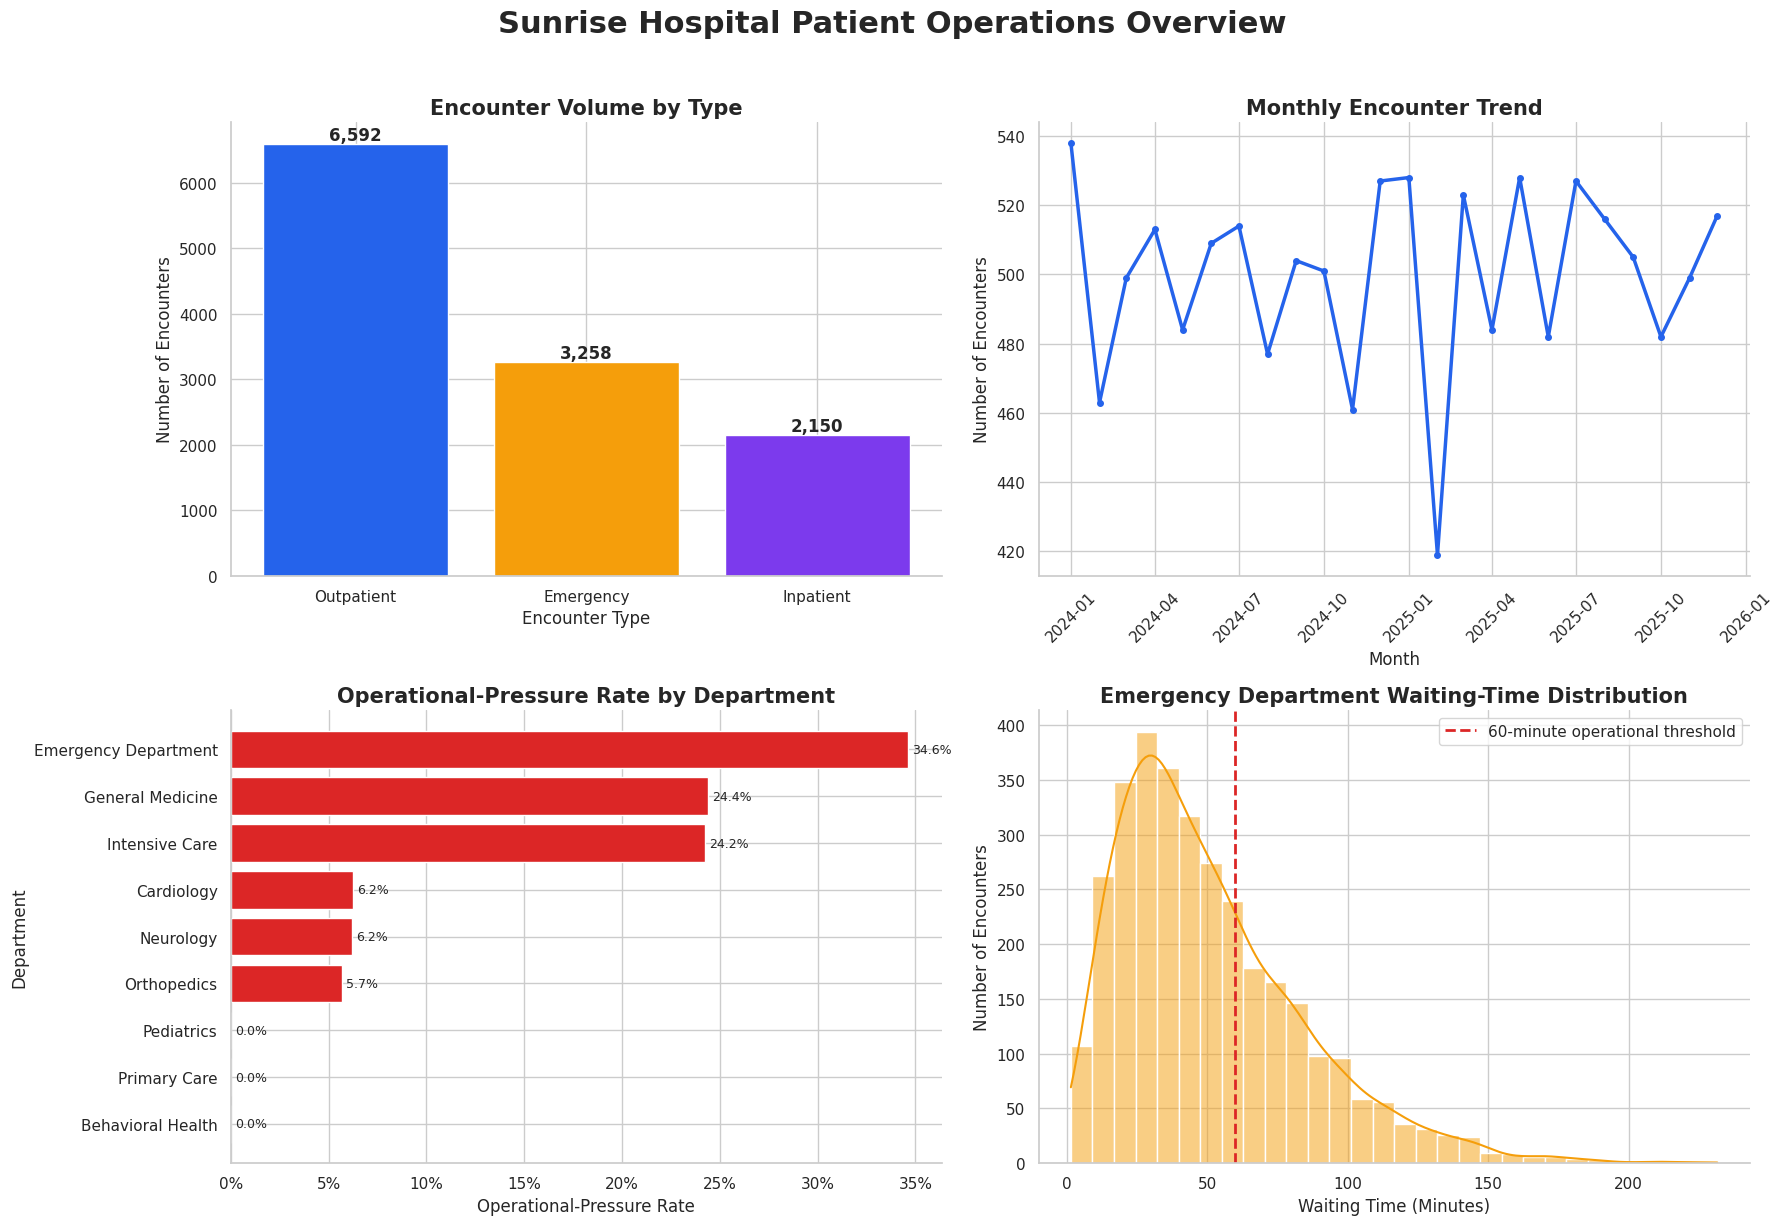

Saved hospital operations overview to: sunrise_hospital_outputs/sunrise-hospital-operations-overview.png


In [21]:
# ---------------------------------------------------------
# Create hospital operations overview
# ---------------------------------------------------------

encounter_type_counts = (
    emr_df["encounter_type"]
    .value_counts()
    .reindex(
        [
            "Outpatient",
            "Emergency",
            "Inpatient"
        ]
    )
)

department_pressure_plot_df = (
    department_summary_df[
        [
            "department",
            "operational_pressure_rate"
        ]
    ]
    .sort_values(
        "operational_pressure_rate",
        ascending=True
    )
)

figure, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(18, 12)
)

figure.suptitle(
    "Sunrise Hospital Patient Operations Overview",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

# ---------------------------------------------------------
# Chart 1: Encounter-type volume
# ---------------------------------------------------------

encounter_colors = [
    "#2563EB",
    "#F59E0B",
    "#7C3AED"
]

axes[0, 0].bar(
    encounter_type_counts.index,
    encounter_type_counts.values,
    color=encounter_colors
)

axes[0, 0].set_title(
    "Encounter Volume by Type",
    fontsize=15,
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "Encounter Type"
)

axes[0, 0].set_ylabel(
    "Number of Encounters"
)

for index, value in enumerate(
    encounter_type_counts.values
):
    axes[0, 0].text(
        index,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# ---------------------------------------------------------
# Chart 2: Monthly encounter trend
# ---------------------------------------------------------

axes[0, 1].plot(
    monthly_summary_df["month_start"],
    monthly_summary_df["total_encounters"],
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=4
)

axes[0, 1].set_title(
    "Monthly Encounter Trend",
    fontsize=15,
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Month"
)

axes[0, 1].set_ylabel(
    "Number of Encounters"
)

axes[0, 1].tick_params(
    axis="x",
    rotation=45
)

# ---------------------------------------------------------
# Chart 3: Operational pressure by department
# ---------------------------------------------------------

axes[1, 0].barh(
    department_pressure_plot_df["department"],
    department_pressure_plot_df[
        "operational_pressure_rate"
    ],
    color="#DC2626"
)

axes[1, 0].set_title(
    "Operational-Pressure Rate by Department",
    fontsize=15,
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Operational-Pressure Rate"
)

axes[1, 0].set_ylabel(
    "Department"
)

axes[1, 0].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, position:
        f"{value:.0%}"
    )
)

for index, value in enumerate(
    department_pressure_plot_df[
        "operational_pressure_rate"
    ]
):
    axes[1, 0].text(
        value + 0.002,
        index,
        f"{value:.1%}",
        va="center",
        fontsize=9
    )

# ---------------------------------------------------------
# Chart 4: Emergency waiting-time distribution
# ---------------------------------------------------------

sns.histplot(
    data=emergency_df,
    x="wait_minutes",
    bins=30,
    kde=True,
    color="#F59E0B",
    ax=axes[1, 1]
)

axes[1, 1].axvline(
    60,
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label="60-minute operational threshold"
)

axes[1, 1].set_title(
    "Emergency Department Waiting-Time Distribution",
    fontsize=15,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Waiting Time (Minutes)"
)

axes[1, 1].set_ylabel(
    "Number of Encounters"
)

axes[1, 1].legend(
    loc="upper right",
    frameon=True
)

# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

for axis in axes.flat:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)

plt.tight_layout()

overview_path = (
    OUTPUT_DIR
    / "sunrise-hospital-operations-overview.png"
)

plt.savefig(
    overview_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "Saved hospital operations overview to:",
    overview_path
)

In [22]:
# ---------------------------------------------------------
# Operational pressure by severity and diagnosis
# ---------------------------------------------------------

severity_summary_df = (
    emr_df
    .groupby(
        "severity",
        as_index=False
    )
    .agg(
        total_encounters=(
            "encounter_id",
            "count"
        ),
        average_wait_minutes=(
            "wait_minutes",
            "mean"
        ),
        average_length_of_stay_hours=(
            "length_of_stay_hours",
            "mean"
        ),
        readmission_30_day_rate=(
            "readmission_30_day_flag",
            "mean"
        ),
        operational_pressure_rate=(
            "operational_pressure_flag",
            "mean"
        )
    )
)

severity_order = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

severity_summary_df["severity"] = pd.Categorical(
    severity_summary_df["severity"],
    categories=severity_order,
    ordered=True
)

severity_summary_df = (
    severity_summary_df
    .sort_values("severity")
    .reset_index(drop=True)
)

severity_summary_df[
    "average_length_of_stay_days"
] = (
    severity_summary_df[
        "average_length_of_stay_hours"
    ]
    / 24
)

severity_summary_df = (
    severity_summary_df
    .drop(
        columns=[
            "average_length_of_stay_hours"
        ]
    )
)

diagnosis_summary_df = (
    emr_df
    .groupby(
        "diagnosis_category",
        as_index=False
    )
    .agg(
        total_encounters=(
            "encounter_id",
            "count"
        ),
        unique_patients=(
            "patient_id",
            "nunique"
        ),
        average_wait_minutes=(
            "wait_minutes",
            "mean"
        ),
        average_length_of_stay_hours=(
            "length_of_stay_hours",
            "mean"
        ),
        readmission_30_day_rate=(
            "readmission_30_day_flag",
            "mean"
        ),
        operational_pressure_rate=(
            "operational_pressure_flag",
            "mean"
        )
    )
)

diagnosis_summary_df[
    "average_length_of_stay_days"
] = (
    diagnosis_summary_df[
        "average_length_of_stay_hours"
    ]
    / 24
)

diagnosis_summary_df = (
    diagnosis_summary_df
    .drop(
        columns=[
            "average_length_of_stay_hours"
        ]
    )
    .sort_values(
        "operational_pressure_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("OPERATIONAL PERFORMANCE BY SEVERITY")
print("=" * 80)

display(
    severity_summary_df.style.format({
        "total_encounters": "{:,.0f}",
        "average_wait_minutes": "{:,.1f}",
        "average_length_of_stay_days": "{:,.2f}",
        "readmission_30_day_rate": "{:.1%}",
        "operational_pressure_rate": "{:.1%}"
    })
)

print("\n" + "=" * 80)
print("OPERATIONAL PERFORMANCE BY DIAGNOSIS CATEGORY")
print("=" * 80)

display(
    diagnosis_summary_df.style.format({
        "total_encounters": "{:,.0f}",
        "unique_patients": "{:,.0f}",
        "average_wait_minutes": "{:,.1f}",
        "average_length_of_stay_days": "{:,.2f}",
        "readmission_30_day_rate": "{:.1%}",
        "operational_pressure_rate": "{:.1%}"
    })
)

OPERATIONAL PERFORMANCE BY SEVERITY


,severity,total_encounters,average_wait_minutes,readmission_30_day_rate,operational_pressure_rate,average_length_of_stay_days
0,Low,"4,998",28.1,0.0%,4.9%,0.09
1,Moderate,"4,372",34.4,0.7%,16.8%,0.87
2,High,"2,057",37.3,1.4%,23.1%,1.71
3,Critical,573,40.8,1.7%,28.1%,1.86



OPERATIONAL PERFORMANCE BY DIAGNOSIS CATEGORY


,diagnosis_category,total_encounters,unique_patients,average_wait_minutes,readmission_30_day_rate,operational_pressure_rate,average_length_of_stay_days
0,Other,675,611,31.6,0.7%,14.4%,0.89
1,Musculoskeletal,"1,613","1,245",33.0,0.5%,14.3%,0.73
2,Neurological,936,817,34.0,0.5%,14.0%,0.71
3,Respiratory,"1,641","1,272",32.6,1.0%,13.9%,0.74
4,Injury,"1,051",892,33.8,0.1%,13.6%,0.77
5,Endocrine,"1,270","1,041",33.4,0.6%,13.5%,0.80
6,Preventive Care,"1,218",999,31.8,0.4%,13.2%,0.82
7,Gastrointestinal,"1,120",929,32.0,0.9%,12.9%,0.77
8,Cardiovascular,"1,668","1,283",32.6,0.5%,12.7%,0.75
9,Behavioral Health,808,713,32.8,0.6%,11.6%,0.68


## 6. Operational Prioritization

Departments are prioritized using encounter volume and the number of operational-pressure events. This is a management-planning indicator—not a clinical-risk score or employee-performance measure.

In [23]:
# ---------------------------------------------------------
# Create department operational-priority table
# ---------------------------------------------------------

department_priority_df = (
    emr_df
    .groupby(
        "department",
        as_index=False
    )
    .agg(
        total_encounters=(
            "encounter_id",
            "count"
        ),
        pressure_encounters=(
            "operational_pressure_flag",
            "sum"
        ),
        extended_wait_encounters=(
            "extended_wait_flag",
            "sum"
        ),
        extended_stay_encounters=(
            "extended_stay_flag",
            "sum"
        ),
        readmission_encounters=(
            "readmission_30_day_flag",
            "sum"
        ),
        incomplete_emergency_encounters=(
            "left_before_completion_flag",
            "sum"
        )
    )
)

department_priority_df[
    "operational_pressure_rate"
] = (
    department_priority_df[
        "pressure_encounters"
    ]
    / department_priority_df[
        "total_encounters"
    ]
)

# Volume-adjusted priority score
department_priority_df[
    "priority_score"
] = (
    department_priority_df[
        "pressure_encounters"
    ]
    * (
        1
        + department_priority_df[
            "operational_pressure_rate"
        ]
    )
)

department_priority_df[
    "priority_rank"
] = (
    department_priority_df[
        "priority_score"
    ]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

def assign_priority_level(row):

    if (
        row["priority_rank"] <= 2
        or row["operational_pressure_rate"] >= 0.25
    ):
        return "High"

    if (
        row["priority_rank"] <= 5
        or row["operational_pressure_rate"] >= 0.10
    ):
        return "Moderate"

    return "Routine Monitoring"


def assign_recommended_action(row):

    if row["extended_wait_encounters"] > 0:
        return (
            "Review patient-flow capacity, triage coverage, "
            "and peak-period waiting times."
        )

    if row["extended_stay_encounters"] > 0:
        return (
            "Review discharge coordination, care transitions, "
            "and extended-stay drivers."
        )

    if row["readmission_encounters"] > 0:
        return (
            "Review follow-up processes and recurring "
            "inpatient utilization."
        )

    return (
        "Continue routine monitoring and validate "
        "department-level data trends."
    )


department_priority_df[
    "priority_level"
] = department_priority_df.apply(
    assign_priority_level,
    axis=1
)

department_priority_df[
    "recommended_operational_review"
] = department_priority_df.apply(
    assign_recommended_action,
    axis=1
)

department_priority_df = (
    department_priority_df
    .sort_values(
        [
            "priority_rank",
            "department"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 90)
print("DEPARTMENT OPERATIONAL-PRIORITY TABLE")
print("=" * 90)

display(
    department_priority_df.style.format({
        "total_encounters": "{:,.0f}",
        "pressure_encounters": "{:,.0f}",
        "extended_wait_encounters": "{:,.0f}",
        "extended_stay_encounters": "{:,.0f}",
        "readmission_encounters": "{:,.0f}",
        "incomplete_emergency_encounters": "{:,.0f}",
        "operational_pressure_rate": "{:.1%}",
        "priority_score": "{:,.1f}",
        "priority_rank": "{:,.0f}"
    })
)

print(
    "\nInterpretation: Priority levels identify areas for "
    "operational review. They do not measure clinical quality "
    "or individual employee performance."
)

DEPARTMENT OPERATIONAL-PRIORITY TABLE


,department,total_encounters,pressure_encounters,extended_wait_encounters,extended_stay_encounters,readmission_encounters,incomplete_emergency_encounters,operational_pressure_rate,priority_score,priority_rank,priority_level,recommended_operational_review
0,Emergency Department,"3,258","1,128","1,043",0,0,131,34.6%,"1,518.5",1,High,"Review patient-flow capacity, triage coverage, and peak-period waiting times."
1,Intensive Care,466,113,0,96,22,0,24.2%,140.4,2,High,"Review discharge coordination, care transitions, and extended-stay drivers."
2,General Medicine,406,99,0,89,14,0,24.4%,123.1,3,Moderate,"Review discharge coordination, care transitions, and extended-stay drivers."
3,Neurology,"1,512",94,0,82,14,0,6.2%,99.8,4,Moderate,"Review discharge coordination, care transitions, and extended-stay drivers."
4,Cardiology,"1,489",93,0,84,14,0,6.2%,98.8,5,Moderate,"Review discharge coordination, care transitions, and extended-stay drivers."
5,Orthopedics,"1,528",87,0,82,7,0,5.7%,92.0,6,Routine Monitoring,"Review discharge coordination, care transitions, and extended-stay drivers."
6,Behavioral Health,"1,097",0,0,0,0,0,0.0%,0.0,7,Routine Monitoring,Continue routine monitoring and validate department-level data trends.
7,Pediatrics,"1,149",0,0,0,0,0,0.0%,0.0,7,Routine Monitoring,Continue routine monitoring and validate department-level data trends.
8,Primary Care,"1,095",0,0,0,0,0,0.0%,0.0,7,Routine Monitoring,Continue routine monitoring and validate department-level data trends.



Interpretation: Priority levels identify areas for operational review. They do not measure clinical quality or individual employee performance.


## 7. Subgroup Monitoring and Responsible Interpretation

Operational indicators are summarized across demographic and insurance groups to identify patterns that may require further investigation. Differences are descriptive and should not be interpreted as discrimination, causation, or clinical evidence without additional validation.

In [24]:
# ---------------------------------------------------------
# Create subgroup monitoring tables
# ---------------------------------------------------------

def create_subgroup_summary(
    data,
    group_column
):
    summary = (
        data
        .groupby(
            group_column,
            as_index=False,
            observed=True
        )
        .agg(
            total_encounters=(
                "encounter_id",
                "count"
            ),
            unique_patients=(
                "patient_id",
                "nunique"
            ),
            average_wait_minutes=(
                "wait_minutes",
                "mean"
            ),
            average_length_of_stay_hours=(
                "length_of_stay_hours",
                "mean"
            ),
            outpatient_no_show_rate=(
                "no_show_flag",
                "mean"
            ),
            readmission_30_day_rate=(
                "readmission_30_day_flag",
                "mean"
            ),
            operational_pressure_rate=(
                "operational_pressure_flag",
                "mean"
            )
        )
    )

    summary[
        "average_length_of_stay_days"
    ] = (
        summary[
            "average_length_of_stay_hours"
        ]
        / 24
    )

    summary = summary.drop(
        columns=[
            "average_length_of_stay_hours"
        ]
    )

    summary["subgroup_dimension"] = (
        group_column
    )

    summary = summary.rename(
        columns={
            group_column: "subgroup"
        }
    )

    return summary


sex_audit_df = create_subgroup_summary(
    emr_df,
    "sex"
)

race_ethnicity_audit_df = create_subgroup_summary(
    emr_df,
    "race_ethnicity"
)

insurance_audit_df = create_subgroup_summary(
    emr_df,
    "insurance_type"
)

age_group_audit_df = create_subgroup_summary(
    emr_df,
    "age_group"
)

subgroup_audit_df = pd.concat(
    [
        sex_audit_df,
        race_ethnicity_audit_df,
        insurance_audit_df,
        age_group_audit_df
    ],
    ignore_index=True
)

subgroup_audit_df = subgroup_audit_df[
    [
        "subgroup_dimension",
        "subgroup",
        "total_encounters",
        "unique_patients",
        "average_wait_minutes",
        "average_length_of_stay_days",
        "outpatient_no_show_rate",
        "readmission_30_day_rate",
        "operational_pressure_rate"
    ]
]

print("=" * 90)
print("SUBGROUP OPERATIONAL MONITORING AUDIT")
print("=" * 90)

display(
    subgroup_audit_df.style.format({
        "total_encounters": "{:,.0f}",
        "unique_patients": "{:,.0f}",
        "average_wait_minutes": "{:,.1f}",
        "average_length_of_stay_days": "{:,.2f}",
        "outpatient_no_show_rate": "{:.1%}",
        "readmission_30_day_rate": "{:.1%}",
        "operational_pressure_rate": "{:.1%}"
    })
)

print(
    "\nImportant: These descriptive differences come from "
    "synthetic data. They are monitoring signals only and "
    "must not be treated as causal, diagnostic, or evidence "
    "of unequal treatment."
)

SUBGROUP OPERATIONAL MONITORING AUDIT


,subgroup_dimension,subgroup,total_encounters,unique_patients,average_wait_minutes,average_length_of_stay_days,outpatient_no_show_rate,readmission_30_day_rate,operational_pressure_rate
0,sex,Female,"6,338","1,554",32.5,0.77,6.3%,0.7%,13.6%
1,sex,Male,"5,662","1,386",33.0,0.75,6.2%,0.5%,13.3%
2,race_ethnicity,Asian,727,176,30.3,0.75,7.4%,0.6%,12.5%
3,race_ethnicity,Black or African American,"3,091",751,32.5,0.80,6.4%,0.7%,13.4%
4,race_ethnicity,Hispanic or Latino,"1,560",393,32.2,0.78,6.6%,0.3%,12.3%
5,race_ethnicity,Other or Multiple,554,136,35.1,0.75,6.5%,0.5%,15.2%
6,race_ethnicity,White,"6,068","1,484",33.1,0.74,5.9%,0.6%,13.7%
7,insurance_type,Commercial,"5,057","2,456",32.3,0.74,6.3%,0.6%,12.9%
8,insurance_type,Medicaid,"2,569","1,695",32.1,0.78,6.3%,0.6%,13.1%
9,insurance_type,Medicare,"3,502","2,055",34.0,0.79,6.2%,0.6%,14.4%



Important: These descriptive differences come from synthetic data. They are monitoring signals only and must not be treated as causal, diagnostic, or evidence of unequal treatment.


## 8. Power BI Data Export

Validated analytical tables are exported to a structured Excel workbook for dashboard development. The workbook includes encounter-level data, KPI summaries, department performance, monthly trends, operational priorities, subgroup monitoring, and data-quality checks.

In [25]:
# ---------------------------------------------------------
# Prepare Power BI export tables
# ---------------------------------------------------------

power_bi_encounters_df = emr_df.copy()

# Excel and Power BI handle timezone-free datetime values
datetime_columns = [
    "date_of_birth",
    "scheduled_datetime",
    "arrival_datetime",
    "discharge_datetime"
]

for column in datetime_columns:
    power_bi_encounters_df[column] = pd.to_datetime(
        power_bi_encounters_df[column]
    )

# Convert categorical fields to text for easier Power BI use
categorical_columns = (
    power_bi_encounters_df
    .select_dtypes(
        include=["category"]
    )
    .columns
)

for column in categorical_columns:
    power_bi_encounters_df[column] = (
        power_bi_encounters_df[column]
        .astype(str)
    )

# Calendar table
calendar_df = pd.DataFrame({
    "date": pd.date_range(
        start=analysis_start.normalize(),
        end=analysis_end.normalize(),
        freq="D"
    )
})

calendar_df["year"] = (
    calendar_df["date"].dt.year
)

calendar_df["quarter"] = (
    "Q"
    + calendar_df["date"]
    .dt.quarter
    .astype(str)
)

calendar_df["month_number"] = (
    calendar_df["date"].dt.month
)

calendar_df["month_name"] = (
    calendar_df["date"].dt.month_name()
)

calendar_df["year_month"] = (
    calendar_df["date"]
    .dt.to_period("M")
    .astype(str)
)

calendar_df["year_month_sort"] = (
    calendar_df["year"] * 100
    + calendar_df["month_number"]
)

calendar_df["day_of_week"] = (
    calendar_df["date"].dt.day_name()
)

calendar_df["day_of_week_number"] = (
    calendar_df["date"].dt.dayofweek + 1
)

calendar_df["is_weekend"] = (
    calendar_df["day_of_week_number"]
    .isin([6, 7])
    .astype(int)
)

# Add a text definition for each KPI
kpi_export_df = kpi_df.copy()

kpi_definitions = {
    "Total Encounters":
        "All scheduled hospital encounters in the analytical period.",

    "Completed Encounters":
        "Encounters with an observed arrival and no no-show flag.",

    "Unique Patients":
        "Distinct synthetic patient identifiers represented in the encounter table.",

    "Average ED Wait":
        "Mean observed waiting time for completed emergency encounters.",

    "Median ED Wait":
        "Median observed waiting time for completed emergency encounters.",

    "Average Inpatient Length of Stay":
        "Mean inpatient encounter duration expressed in days.",

    "Median Inpatient Length of Stay":
        "Median inpatient encounter duration expressed in days.",

    "Outpatient No-Show Rate":
        "Share of outpatient appointments with a no-show indicator.",

    "30-Day Inpatient Readmission Rate":
        "Share of inpatient encounters occurring within 30 days of a previous inpatient discharge.",

    "ED Wait Over 60 Minutes":
        "Share of completed emergency encounters with waiting time exceeding 60 minutes.",

    "Inpatient Stay Over 5 Days":
        "Share of inpatient encounters lasting longer than 120 hours.",

    "Operational-Pressure Encounter Rate":
        "Share of encounters with an extended wait, extended stay, readmission, or incomplete emergency visit."
}

kpi_export_df["Definition"] = (
    kpi_export_df["KPI"]
    .map(kpi_definitions)
)

# ---------------------------------------------------------
# Export workbook and CSV dataset
# ---------------------------------------------------------

excel_output_path = (
    OUTPUT_DIR
    / "sunrise-hospital-dashboard-data.xlsx"
)

csv_output_path = (
    OUTPUT_DIR
    / "synthetic-hospital-encounters.csv"
)

with pd.ExcelWriter(
    excel_output_path,
    engine="openpyxl",
    datetime_format="yyyy-mm-dd hh:mm:ss",
    date_format="yyyy-mm-dd"
) as writer:

    power_bi_encounters_df.to_excel(
        writer,
        sheet_name="Encounters",
        index=False
    )

    patients_df.to_excel(
        writer,
        sheet_name="Patients",
        index=False
    )

    calendar_df.to_excel(
        writer,
        sheet_name="Calendar",
        index=False
    )

    kpi_export_df.to_excel(
        writer,
        sheet_name="KPI Summary",
        index=False
    )

    department_summary_df.to_excel(
        writer,
        sheet_name="Department Summary",
        index=False
    )

    monthly_summary_df.to_excel(
        writer,
        sheet_name="Monthly Summary",
        index=False
    )

    severity_summary_df.to_excel(
        writer,
        sheet_name="Severity Summary",
        index=False
    )

    diagnosis_summary_df.to_excel(
        writer,
        sheet_name="Diagnosis Summary",
        index=False
    )

    department_priority_df.to_excel(
        writer,
        sheet_name="Department Priority",
        index=False
    )

    subgroup_audit_df.to_excel(
        writer,
        sheet_name="Subgroup Audit",
        index=False
    )

    validation_df.to_excel(
        writer,
        sheet_name="Data Validation",
        index=False
    )

power_bi_encounters_df.to_csv(
    csv_output_path,
    index=False
)

print("=" * 80)
print("EXPORT COMPLETED")
print("=" * 80)
print("Power BI workbook:", excel_output_path)
print("Encounter CSV:", csv_output_path)
print(
    "Workbook sheets:",
    11
)
print(
    "Encounter rows exported:",
    f"{len(power_bi_encounters_df):,}"
)

EXPORT COMPLETED
Power BI workbook: sunrise_hospital_outputs/sunrise-hospital-dashboard-data.xlsx
Encounter CSV: sunrise_hospital_outputs/synthetic-hospital-encounters.csv
Workbook sheets: 11
Encounter rows exported: 12,000


In [26]:
# ---------------------------------------------------------
# Package exported project files for download
# ---------------------------------------------------------

import shutil
from google.colab import files

archive_base_path = "sunrise-hospital-emr-project-files"

archive_path = shutil.make_archive(
    base_name=archive_base_path,
    format="zip",
    root_dir=OUTPUT_DIR
)

print(
    "Project archive created:",
    archive_path
)

files.download(archive_path)

Project archive created: /content/sunrise-hospital-emr-project-files.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Executive Summary and Recommendations

This synthetic hospital-operations analysis demonstrates how encounter-level EMR data can support administrative monitoring and resource planning.

### Management Interpretation

- Encounter volume should be monitored over time to identify changes in service demand.
- Emergency Department waiting time requires particular attention because prolonged waits may indicate capacity or patient-flow pressure.
- Extended inpatient stays should be reviewed alongside discharge coordination and care-transition processes.
- Outpatient no-shows may create unused capacity and delayed access to care.
- Thirty-day inpatient readmissions provide a monitoring signal for recurring utilization, but they do not independently measure quality of care.
- Department-priority indicators should guide further investigation rather than automatic conclusions.

### Recommended Actions

1. Review Emergency Department staffing and patient-flow capacity during high-demand periods.
2. Examine the operational causes of inpatient stays exceeding five days.
3. Monitor outpatient no-show patterns and evaluate reminder or scheduling interventions.
4. Review recurring inpatient utilization using appropriate clinical and operational context.
5. Maintain subgroup monitoring while protecting patient privacy.
6. Validate all thresholds, definitions, and recommendations before any real-world use.

## Limitations

- All records are synthetic and were generated using explicit assumptions.
- The data does not represent Sunrise Hospital or any real healthcare organization.
- Operational thresholds were selected for demonstration rather than clinical validation.
- Associations in the data are not causal findings.
- The readmission indicator is simplified and does not include exclusions commonly used in formal hospital-quality measures.
- No diagnosis, treatment, or patient-level clinical decision should be based on this project.

## Conclusion

The project demonstrates a reproducible workflow for transforming synthetic EMR-style encounter data into validated operational KPIs, management-priority tables, responsible subgroup monitoring, and dashboard-ready datasets.